<a href="https://www.kaggle.com/code/shamanthakreddymallu/s6e7-baseline-lightgbm?scriptVersionId=332261749" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports & Load

In [1]:
# PATHS
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e7/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e7/test.csv'
SAMPLE_PATH   = '/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from itertools import product
import warnings
warnings.filterwarnings('ignore')

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

TARGET       = 'health_condition'
CLASS_ORDER  = ['at-risk', 'fit', 'unhealthy']   # LabelEncoder alphabetical order
CLASS_COLORS = {'fit': '#55A868', 'at-risk': '#4C72B0', 'unhealthy': '#C44E52'}

CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']
NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']

# Standardise categorical strings everywhere (keep NaN as NaN)
for df in [train, test, original]:
    for c in CAT_COLS:
        df[c] = df[c].astype(str).str.strip().str.lower().replace('nan', np.nan)

original[TARGET] = original[TARGET].astype(str).str.strip().str.lower()
original = original.drop(columns=['student_id', 'timestamp'])

print(f'Train    : {train.shape}')
print(f'Test     : {test.shape}')
print(f'Original : {original.shape}')

Train    : (690088, 15)
Test     : (295753, 14)
Original : (50000, 14)


# Feature Engineering

Driven directly by EDA findings:
- `stress_level` gates the target (medium -> at-risk; fit lives in low; unhealthy lives in high)
- `physical_activity_level` is a second gate for fit (active -> 17% fit, else ~0.3%)
- `sleep_duration` is the top boundary feature (unhealthy = short sleep within high stress; fit = long sleep + high steps + exercise within low stress)
- `sleep_quality` / `smoking_alcohol` softly gate unhealthy
- heart_rate, water_intake, calorie, diet, gender ~ near-noise (kept, trees can ignore them)

In [3]:
def engineer_features(df):
    df = df.copy()

    # ---- Gate interactions (the key features) ----
    # stress x activity: fit requires (low, active) jointly
    df['stress_x_activity'] = (df['stress_level'].fillna('na') + '_' +
                               df['physical_activity_level'].fillna('na'))
    # stress x sleep_quality: unhealthy concentrates in (high, poor)
    df['stress_x_sleepq']   = (df['stress_level'].fillna('na') + '_' +
                               df['sleep_quality'].fillna('na'))
    # stress x smoking
    df['stress_x_smoke']    = (df['stress_level'].fillna('na') + '_' +
                               df['smoking_alcohol'].fillna('na'))

    # ---- Numeric boundary helpers ----
    # short sleep flag (unhealthy boundary within high stress sits ~<6h)
    df['sleep_lt6']    = (df['sleep_duration'] < 6).astype(float)
    df['sleep_lt6']    = df['sleep_lt6'].where(df['sleep_duration'].notna())
    # long sleep + activity composite (fit boundary within low stress)
    df['sleep_ge7']    = (df['sleep_duration'] >= 7).astype(float)
    df['sleep_ge7']    = df['sleep_ge7'].where(df['sleep_duration'].notna())

    # activity composites
    df['steps_x_exercise']    = df['step_count'] * df['exercise_duration']
    df['activity_efficiency'] = df['calorie_expenditure'] / df['step_count'].replace(0, np.nan)
    df['sleep_x_steps']       = df['sleep_duration'] * df['step_count']

    # bmi bands (WHO-ish) as numeric ordinal
    df['bmi_band'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(float)

    # deviation from healthy sleep midpoint
    df['sleep_dev'] = (df['sleep_duration'] - 7.5).abs()

    return df

train    = engineer_features(train)
test     = engineer_features(test)
original = engineer_features(original)

ENGINEERED_CATS = ['stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke']
ENGINEERED_NUMS = ['sleep_lt6', 'sleep_ge7', 'steps_x_exercise',
                   'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev']

print('Engineered:', ENGINEERED_CATS + ENGINEERED_NUMS)

Engineered: ['stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke', 'sleep_lt6', 'sleep_ge7', 'steps_x_exercise', 'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev']


## Categorical Encoding

All categoricals are low-cardinality with a natural or learnable order — use pandas `category` dtype and let LightGBM handle them natively (handles NaN too).

In [4]:
FEATURES = NUM_COLS + CAT_COLS + ENGINEERED_CATS + ENGINEERED_NUMS
LGB_CATS = CAT_COLS + ENGINEERED_CATS

# Unified category dtypes across train/test/original so codes align
for c in LGB_CATS:
    all_cats = pd.concat([train[c], test[c], original[c]]).dropna().unique()
    cat_type = pd.CategoricalDtype(categories=sorted(all_cats))
    train[c]    = train[c].astype(cat_type)
    test[c]     = test[c].astype(cat_type)
    original[c] = original[c].astype(cat_type)

print(f'{len(FEATURES)} features ({len(LGB_CATS)} categorical)')
print(FEATURES)

23 features (9 categorical)
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke', 'sleep_lt6', 'sleep_ge7', 'steps_x_exercise', 'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev']


## Integrate Original Data

Adversarial AUC was 0.83 (distinguishable — tighter tails in Kaggle data), so the original is appended to **training folds only**, never validated on. Set `USE_ORIGINAL = False` to A/B its contribution against pure-Kaggle CV.

In [5]:
USE_ORIGINAL = True

train['source']    = 'kaggle'
original['source'] = 'original'

train_augmented = pd.concat(
    [train[FEATURES + [TARGET, 'source']],
     original[FEATURES + [TARGET, 'source']] if USE_ORIGINAL else
     original[FEATURES + [TARGET, 'source']].iloc[0:0]],
    ignore_index=True
)

print(f'Augmented: {len(train_augmented):,} rows '
      f'({(train_augmented.source=="kaggle").sum():,} kaggle + '
      f'{(train_augmented.source=="original").sum():,} original)')
print(train_augmented.groupby('source')[TARGET].value_counts().unstack(fill_value=0))

Augmented: 740,088 rows (690,088 kaggle + 50,000 original)
health_condition  at-risk    fit  unhealthy
source                                     
kaggle             592561  39803      57724
original            43718   2466       3816


## Sanity Checks

In [6]:
print('NaN summary on FEATURES (kaggle train part) — LightGBM handles these natively:')
nan_pct = (train[FEATURES].isna().mean() * 100).round(2)
print(nan_pct[nan_pct > 0].sort_values(ascending=False).to_string())

# no infs
inf_cols = []
for c in [f for f in FEATURES if f not in LGB_CATS]:
    if np.isinf(train[c].astype(float)).any():
        inf_cols.append(c)
print('\nInf columns:', inf_cols if inf_cols else 'none')

print(f'\ntrain[FEATURES]: {train[FEATURES].shape}')
print(f'test[FEATURES] : {test[FEATURES].shape}')

NaN summary on FEATURES (kaggle train part) — LightGBM handles these natively:
sleep_x_steps              12.81
stress_level               12.00
sleep_duration             11.01
sleep_lt6                  11.01
sleep_ge7                  11.01
sleep_dev                  11.01
activity_efficiency         9.52
sleep_quality               8.45
calorie_expenditure         7.66
water_intake                6.30
physical_activity_level     5.31
smoking_alcohol             4.14
gender                      3.10
steps_x_exercise            3.00
step_count                  2.02
bmi                         2.01
bmi_band                    2.01
heart_rate                  1.14
exercise_duration           1.00
diet_type                   1.00

Inf columns: none

train[FEATURES]: (690088, 23)
test[FEATURES] : (295753, 23)


# Modeling — LightGBM, Stratified 5-Fold

- `class_weight='balanced'` so the model doesn't collapse onto at-risk
- Original rows appended to train folds only; validation always pure Kaggle
- OOF probabilities saved for post-hoc decision-rule optimization

In [7]:
le = LabelEncoder()
y_aug = le.fit_transform(train_augmented[TARGET])
print('Class encoding:', dict(zip(le.classes_, range(len(le.classes_)))))

N_FOLDS   = 5
SEED      = 42
N_CLASSES = 3

kag_idx  = np.where(train_augmented['source'] == 'kaggle')[0]
orig_idx = np.where(train_augmented['source'] == 'original')[0]

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(kag_idx, y_aug[kag_idx]))

LGB_PARAMS = dict(
    objective        = 'multiclass',
    num_class        = N_CLASSES,
    metric           = 'multi_logloss',
    learning_rate    = 0.05,
    num_leaves       = 127,
    min_child_samples= 100,
    feature_fraction = 0.85,
    bagging_fraction = 0.85,
    bagging_freq     = 1,
    lambda_l2        = 1.0,
    n_estimators     = 3000,
    class_weight     = 'balanced',
    random_state     = SEED,
    n_jobs           = -1,
    verbose          = -1,
)

Class encoding: {'at-risk': 0, 'fit': 1, 'unhealthy': 2}


In [8]:
oof_probs   = np.zeros((len(kag_idx), N_CLASSES))
test_probs  = np.zeros((len(test), N_CLASSES))
fold_scores, models, fi_list = [], [], []

X_test = test[FEATURES]

for fold, (tr_kag, val_kag) in enumerate(FOLD_SPLITS, 1):
    tr_idx  = np.concatenate([kag_idx[tr_kag], orig_idx])
    val_idx = kag_idx[val_kag]

    Xtr, ytr = train_augmented.iloc[tr_idx][FEATURES], y_aug[tr_idx]
    Xvl, yvl = train_augmented.iloc[val_idx][FEATURES], y_aug[val_idx]

    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(
        Xtr, ytr,
        eval_set=[(Xvl, yvl)],
        eval_metric='multi_logloss',
        categorical_feature=LGB_CATS,
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )

    val_p = model.predict_proba(Xvl)
    oof_probs[val_kag] = val_p
    test_probs += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(yvl, val_p.argmax(1))
    fold_scores.append(score)
    models.append(model)
    fi_list.append(pd.Series(model.booster_.feature_importance(importance_type='gain'),
                         index=FEATURES, name=f'fold{fold}'))
    print(f'Fold {fold}: balanced_acc = {score:.5f}  (best_iter={model.best_iteration_})')

y_kag = y_aug[kag_idx]
raw_oof_score = balanced_accuracy_score(y_kag, oof_probs.argmax(1))
print(f'\nRaw OOF (argmax): {raw_oof_score:.5f}')
print(f'CV mean         : {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}')

np.save('oof_lgb.npy', oof_probs)
np.save('test_lgb.npy', test_probs)

Fold 1: balanced_acc = 0.92312  (best_iter=1490)
Fold 2: balanced_acc = 0.92493  (best_iter=1474)
Fold 3: balanced_acc = 0.92375  (best_iter=1517)
Fold 4: balanced_acc = 0.92236  (best_iter=1463)
Fold 5: balanced_acc = 0.92295  (best_iter=1418)

Raw OOF (argmax): 0.92342
CV mean         : 0.92342 +/- 0.00087


# Decision-Rule Optimization on OOF

The highest-leverage step for balanced accuracy: search per-class probability multipliers on OOF, pick weights maximizing balanced accuracy, apply the same weights to test. Coarse grid + local refinement (same approach that worked in S6E6).

In [9]:
def optimize_class_weights(probs, y_true, coarse=25, refine=25):
    # class 0 = at-risk anchored at 1.0; search fit (1) and unhealthy (2)
    grid = np.exp(np.linspace(np.log(0.5), np.log(40), 31))
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wf, wu in product(grid, grid):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    step = (grid[1] - grid[0]) / 2
    ff = np.linspace(best_w[1] - step, best_w[1] + step, refine)
    fu = np.linspace(best_w[2] - step, best_w[2] + step, refine)
    for wf, wu in product(ff, fu):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    return best_w, best_score

global_w, opt_oof_score = optimize_class_weights(oof_probs, y_kag)

print(f'Raw  OOF balanced accuracy : {raw_oof_score:.5f}')
print(f'Optimized weights          : {dict(zip(le.classes_, global_w.round(4)))}')
print(f'Opt. OOF balanced accuracy : {opt_oof_score:.5f}   (+{opt_oof_score - raw_oof_score:.5f})')

Raw  OOF balanced accuracy : 0.92342
Optimized weights          : {'at-risk': np.float64(1.0), 'fit': np.float64(16.6707), 'unhealthy': np.float64(12.4426)}
Opt. OOF balanced accuracy : 0.94848   (+0.02506)


In [10]:
# --- Segmented decision rule: separate weights for stress-present / stress-missing ---
stress_missing_tr = train['stress_level'].isna().values     # aligns with oof_probs rows
stress_missing_te = test['stress_level'].isna().values

seg_weights = {}
for name, mask in [('present', ~stress_missing_tr), ('missing', stress_missing_tr)]:
    w, s = optimize_class_weights(oof_probs[mask], y_kag[mask])
    seg_weights[name] = w
    print(f'{name:8s}: weights={w.round(3)}  seg_balanced_acc={s:.5f}')

# combined OOF score with segmented rule
preds_seg = np.empty(len(y_kag), dtype=int)
preds_seg[~stress_missing_tr] = (oof_probs[~stress_missing_tr] * seg_weights['present']).argmax(1)
preds_seg[stress_missing_tr]  = (oof_probs[stress_missing_tr]  * seg_weights['missing']).argmax(1)
seg_oof_score = balanced_accuracy_score(y_kag, preds_seg)
print(f'\nGlobal-weight OOF : {opt_oof_score:.5f}')
print(f'Segmented OOF     : {seg_oof_score:.5f}   (+{seg_oof_score - opt_oof_score:.5f})')

present : weights=[ 1.     9.286 12.42 ]  seg_balanced_acc=0.96113
missing : weights=[ 1.    25.768 12.407]  seg_balanced_acc=0.85741

Global-weight OOF : 0.94848
Segmented OOF     : 0.94868   (+0.00020)


# Post-Modeling Analysis

## OOF Score + Confusion Matrix

OOF Balanced Accuracy (optimized): 0.94848

              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    592561
         fit       0.73      0.95      0.83     39803
   unhealthy       0.68      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.80      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



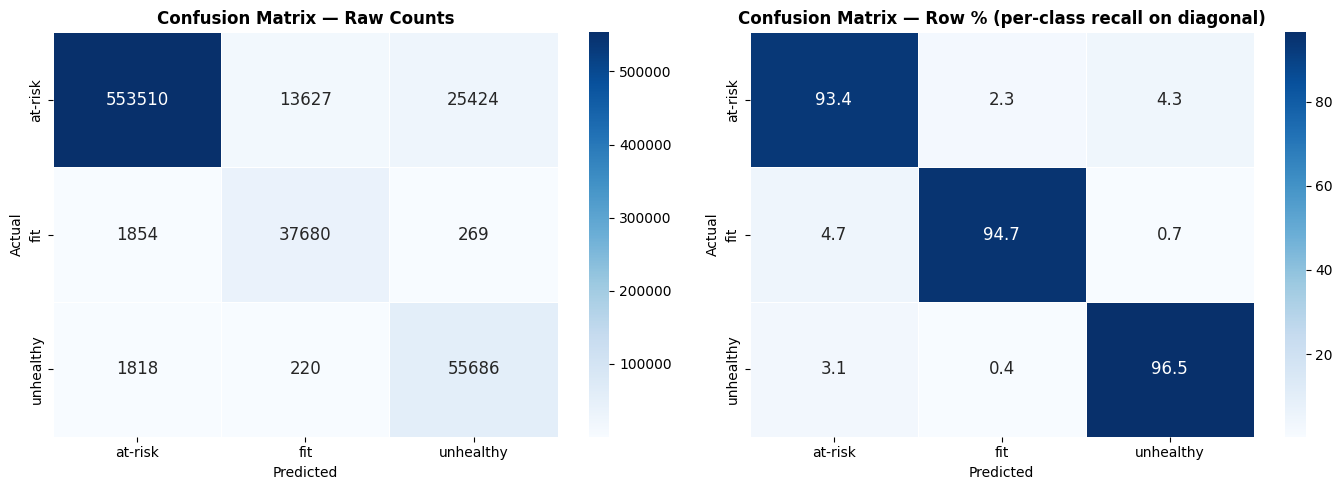

In [11]:
probs_w   = oof_probs * global_w
preds_kag = probs_w.argmax(1)

cm     = confusion_matrix(y_kag, preds_kag)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print(f'OOF Balanced Accuracy (optimized): {opt_oof_score:.5f}')
print()
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix — Row % (per-class recall on diagonal)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Subgroup Check — Stress-Missing Rows

The 12% of rows without `stress_level` can't use the main gate; balanced accuracy there will lag. Tracking it separately tells us how much headroom is left in these rows.

In [12]:
train_kag = train.reset_index(drop=True)   # same order as kag_idx rows in augmented frame
stress_missing_mask = train_kag['stress_level'].isna().values

for name, mask in [('stress present', ~stress_missing_mask),
                   ('stress MISSING', stress_missing_mask)]:
    s = balanced_accuracy_score(y_kag[mask], preds_kag[mask])
    print(f'{name:16s}: balanced_acc = {s:.5f}   (n={mask.sum():,})')
    print(classification_report(y_kag[mask], preds_kag[mask],
                                 target_names=le.classes_, digits=3))

stress present  : balanced_acc = 0.96102   (n=607,277)
              precision    recall  f1-score   support

     at-risk      0.994     0.966     0.980    521431
         fit      0.874     0.949     0.910     35044
   unhealthy      0.788     0.968     0.869     50802

    accuracy                          0.965    607277
   macro avg      0.885     0.961     0.920    607277
weighted avg      0.970     0.965     0.966    607277

stress MISSING  : balanced_acc = 0.85656   (n=82,811)
              precision    recall  f1-score   support

     at-risk      0.989     0.700     0.820     71130
         fit      0.328     0.932     0.486      4759
   unhealthy      0.342     0.938     0.502      6922

    accuracy                          0.733     82811
   macro avg      0.553     0.857     0.602     82811
weighted avg      0.897     0.733     0.774     82811



## Feature Importance

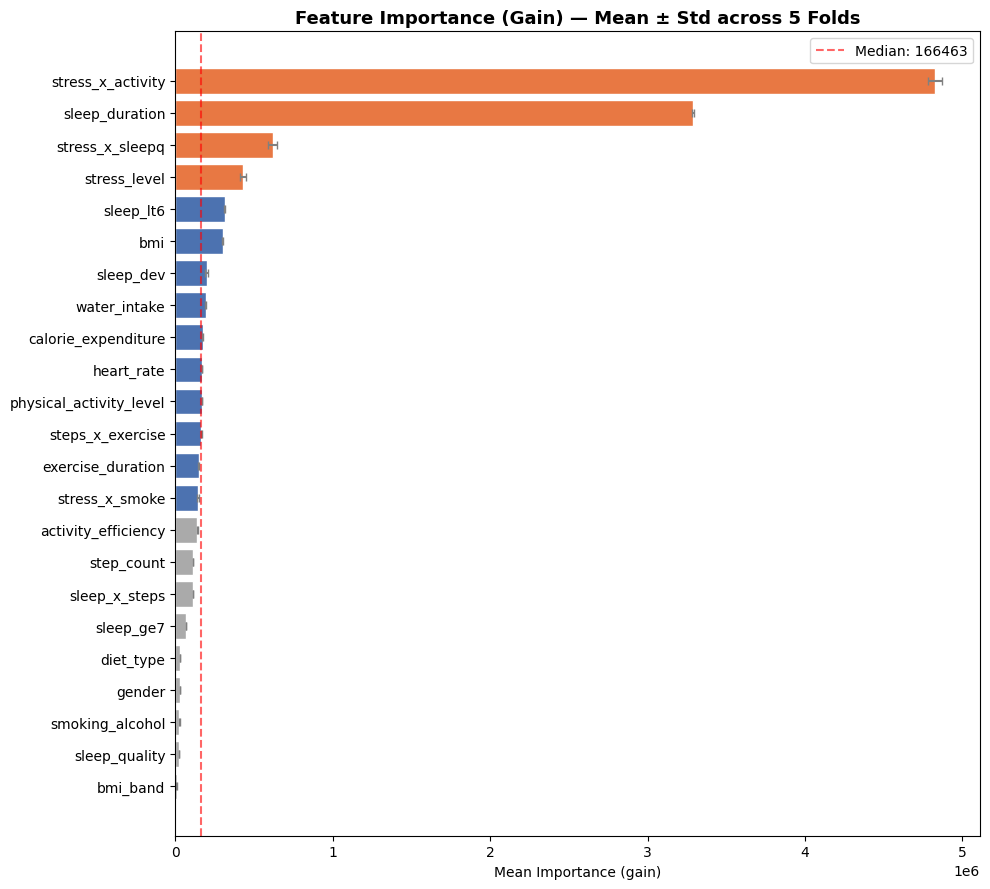

Top 15 features:
stress_x_activity          4825732.1
sleep_duration             3287790.1
stress_x_sleepq             619581.7
stress_level                432907.8
sleep_lt6                   313041.2
bmi                         303001.9
sleep_dev                   198912.2
water_intake                194124.6
calorie_expenditure         174844.7
heart_rate                  172137.3
physical_activity_level     171005.6
steps_x_exercise            166463.4
exercise_duration           149001.3
stress_x_smoke              147174.7
activity_efficiency         140082.4


In [13]:
fi_mean = pd.concat(fi_list, axis=1).mean(axis=1).sort_values(ascending=False)
fi_std  = pd.concat(fi_list, axis=1).std(axis=1)
fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = [
    '#E87843' if fi_mean[f] >= fi_mean.quantile(0.85) else
    '#4C72B0' if fi_mean[f] >= fi_mean.quantile(0.40) else
    '#AAAAAA'
    for f in fi_mean.index
]
ax.barh(fi_mean.index[::-1], fi_mean.values[::-1],
        xerr=fi_std.reindex(fi_mean.index[::-1]).values,
        color=bar_colors[::-1], edgecolor='white', capsize=3, ecolor='gray')
ax.axvline(fi_mean.median(), color='red', linestyle='--', alpha=0.6,
           label=f'Median: {fi_mean.median():.0f}')
ax.set_xlabel('Mean Importance (gain)')
ax.set_title('Feature Importance (Gain) — Mean ± Std across 5 Folds', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print('Top 15 features:')
print(fi_mean.head(15).round(1).to_string())

## Error Analysis

In [14]:
error_df = train_kag[['stress_level', 'physical_activity_level', 'sleep_quality',
                       'sleep_duration', 'step_count', TARGET]].copy()
error_df['y_true']   = le.inverse_transform(y_kag)
error_df['y_pred']   = le.inverse_transform(preds_kag)
error_df['correct']  = error_df['y_true'] == error_df['y_pred']
error_df['max_prob'] = probs_w.max(1) / probs_w.sum(1)

errors = error_df[~error_df['correct']]
print(f'Total errors: {len(errors):,} ({len(errors)/len(error_df)*100:.2f}%)')

print('\nError breakdown by TRUE class:')
print(errors.groupby('y_true').size().to_string())

print('\nTop confusion cells (true -> pred):')
print(errors.groupby(['y_true', 'y_pred']).size().sort_values(ascending=False).head(6).to_string())

print('\nErrors by stress_level:')
print(errors.groupby(errors['stress_level'].astype(str)).size().to_string())

print('\nMissed fit rows — where do they live?')
missed_fit = errors[errors['y_true'] == 'fit']
print(pd.crosstab(missed_fit['stress_level'].astype(str),
                  missed_fit['physical_activity_level'].astype(str)).to_string())

Total errors: 43,212 (6.26%)

Error breakdown by TRUE class:
y_true
at-risk      39051
fit           2123
unhealthy     2038

Top confusion cells (true -> pred):
y_true     y_pred   
at-risk    unhealthy    25424
           fit          13627
fit        at-risk       1854
unhealthy  at-risk       1818
fit        unhealthy      269
unhealthy  fit            220

Errors by stress_level:
stress_level
high      13955
low        5198
medium     1980
nan       22079

Missed fit rows — where do they live?
physical_activity_level  active  moderate  nan  sedentary
stress_level                                             
high                        223       203   30        164
low                         116       132   36        109
medium                      290       271   38        186
nan                         135        78   41         71


# Submission

Using SEGMENTED weights: present=[ 1.     9.286 12.42 ], missing=[ 1.    25.768 12.407]
Saved: submission.csv

Predicted class distribution (test):
at-risk      239265
unhealthy     34916
fit           21572

Train distribution for reference:
health_condition
at-risk      592561
unhealthy     57724
fit           39803


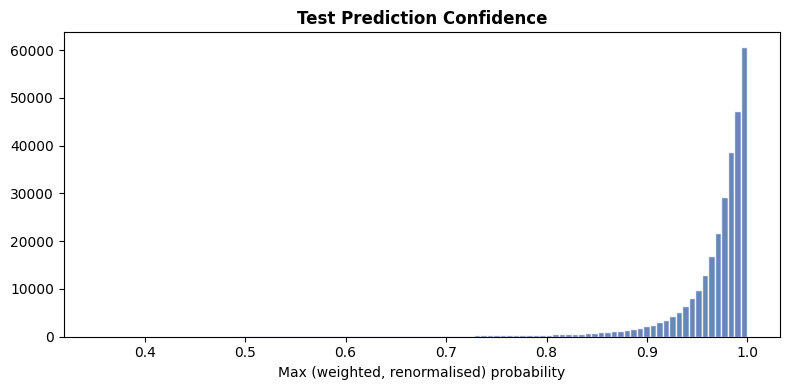

In [15]:
if 'seg_weights' in dir():
    test_w = np.empty_like(test_probs)
    test_w[~stress_missing_te] = test_probs[~stress_missing_te] * seg_weights['present']
    test_w[stress_missing_te]  = test_probs[stress_missing_te]  * seg_weights['missing']
    print(f'Using SEGMENTED weights: present={seg_weights["present"].round(3)}, '
          f'missing={seg_weights["missing"].round(3)}')
else:
    test_w = test_probs * global_w
    print(f'Using GLOBAL weights: {global_w.round(3)}')

labels = le.inverse_transform(test_w.argmax(1))

sub = pd.read_csv(SAMPLE_PATH)
sub[TARGET] = labels
sub.to_csv('submission.csv', index=False)
print('Saved: submission.csv')
print('\nPredicted class distribution (test):')
print(pd.Series(labels).value_counts().to_string())
print('\nTrain distribution for reference:')
print(train[TARGET].value_counts().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
norm_p = test_w / test_w.sum(1, keepdims=True)
ax.hist(norm_p.max(1), bins=100, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Max (weighted, renormalised) probability')
ax.set_title('Test Prediction Confidence', fontweight='bold')
plt.tight_layout(); plt.show()